In [1]:
%pip install clouddrift cartopy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import clouddrift as cd

In [3]:
ds = cd.datasets.gdp1h()

In [7]:
ds
ds.info()

xarray.Dataset {
dimensions:
	traj = 19396 ;
	obs = 197214787 ;

variables:
	|S20 BuoyTypeManufacturer(traj) ;
		BuoyTypeManufacturer:long_name = Buoy type manufacturer ;
		BuoyTypeManufacturer:units = - ;
	|S20 BuoyTypeSensorArray(traj) ;
		BuoyTypeSensorArray:long_name = Buoy type sensor array ;
		BuoyTypeSensorArray:units = - ;
	float64 CurrentProgram(traj) ;
		CurrentProgram:long_name = Current Program ;
		CurrentProgram:units = - ;
	|S20 DeployingCountry(traj) ;
		DeployingCountry:long_name = Deploying country ;
		DeployingCountry:units = - ;
	|S20 DeployingShip(traj) ;
		DeployingShip:long_name = Name of deployment ship ;
		DeployingShip:units = - ;
	int16 DeploymentComments(traj) ;
		DeploymentComments:long_name = Deployment comments ;
		DeploymentComments:units = - ;
	|S20 DeploymentStatus(traj) ;
		DeploymentStatus:long_name = Deployment status ;
		DeploymentStatus:units = - ;
	float32 DragAreaAboveDrogue(traj) ;
		DragAreaAboveDrogue:long_name = Drag area above drogue. ;
		Dr

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lat = ds['lat'].values.astype(np.float32)
lon = ds['lon'].values.astype(np.float32)

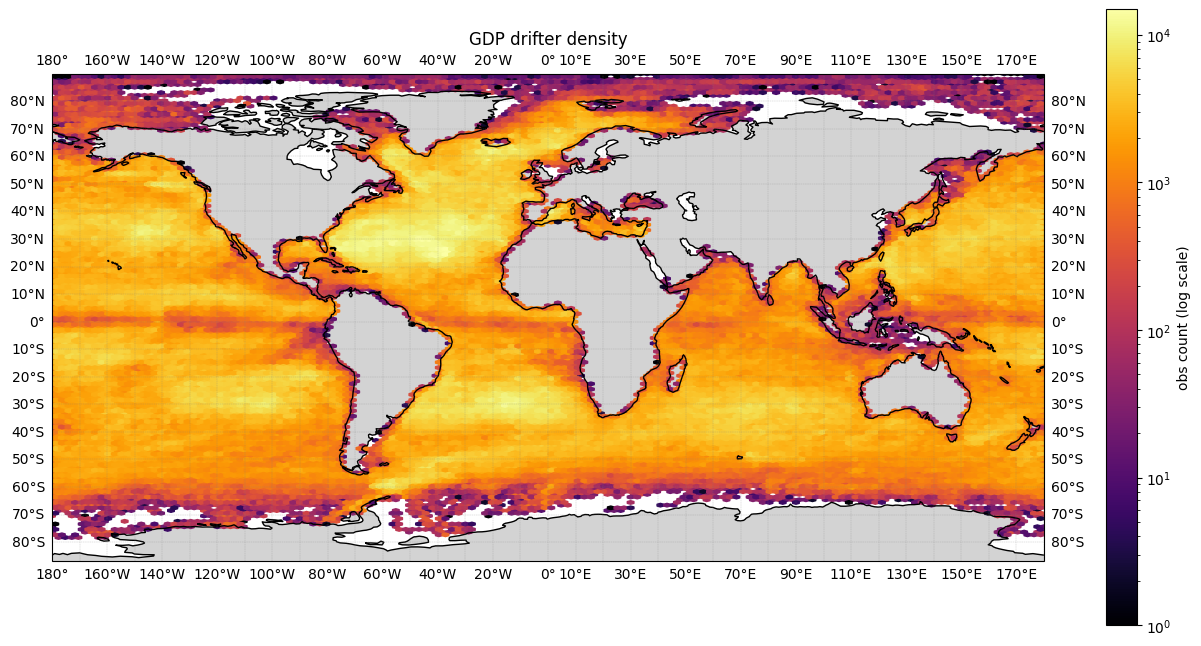

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(16,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE)
hb = ax.hexbin(lon[::5], lat[::5], gridsize=150, bins='log', cmap='inferno', transform=ccrs.PlateCarree())
plt.colorbar(hb, label='obs count (log scale)')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--',
                  xlocs=np.arange(-180, 181, 10), ylocs=np.arange(-90, 91, 10))
ax.set_title('GDP drifter density')
plt.show()